# Load packages

In [1]:
import scimap as sm

import sys
import anndata as ad
import seaborn as sns; sns.set(color_codes=True)
import numpy as np

import scanpy as sc
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy import stats

Running SCIMAP  2.2.11


# Load data

In [2]:
data = pd.read_csv('/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv', index_col=0)

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_94942/1161626377.py:1: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



In [7]:
data.columns

Index(['S9.6', 'HER3', 'panCK', 'SMA', 'CD45', 'Ki67_2', 'CD4', 'FOXP3',
       'CD8a', 'CD11b', 'CD68', 'CD206', 'H2ax', 'Vimentin', 'H3K27me3',
       'E.Cadherin', 'GCLC', 'TXNRD1', 'NQO1', 'pERK', 'TXN', 'pSTAT3',
       'pS6_235', 'pRB', 'GLUT1', 'X_centroid', 'Y_centroid', 'imageid',
       'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage',
       'patient_id_AB19_1654', 'Area', 'Eccentricity', 'antioxidant_NQOI',
       'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1',
       'NQO1_GCLC_VIM', 'celltype_2', 'celltype_1', 'Tumor_state', 'GCLC_VIM',
       'CellCategory', 'SC45px_neigh_kmeans_10', 'RCNs'],
      dtype='object')

In [8]:
data_sub = data[['imageid', 'core_imageid', 'Annotation', 'patient_id_AB19_1654']]

In [9]:
data_sub

,imageid,core_imageid,Annotation,patient_id_AB19_1654
CellID,,,,
1,19_02_02A,core77_19_02_02A,Invasive border,AB19-1654_P10158
10,19_02_01A,core77_19_02_01A,Tumor center,AB19-1654_P10117
10,19_02_02A,core77_19_02_02A,Invasive border,AB19-1654_P10158
100,19_02_01A,core77_19_02_01A,Tumor center,AB19-1654_P10117
100,19_02_02A,core77_19_02_02A,Invasive border,AB19-1654_P10158
...,...,...,...,...
99998,INF1,core22_INF1,Inflammation,AB19-1654_P10648
99999,1B,core64_1B,Tumor center,AB19-1654_P10561
99999,2B,core71_2B,Lymph node met,AB19-1654_P10599


In [13]:
# cells per core and summary stats
cells_per_core = data_sub.groupby('core_imageid').size()
print(f"Number of cores: {cells_per_core.size}")
print(f"Average cells per core: {cells_per_core.mean():.1f}")
print(f"Median cells per core: {cells_per_core.median():.1f}")
print(cells_per_core.describe())


Number of cores: 345
Average cells per core: 10671.8
Median cells per core: 9897.0
count      345.000000
mean     10671.802899
std       5856.856593
min        706.000000
25%       6523.000000
50%       9897.000000
75%      13865.000000
max      33800.000000
dtype: float64


In [3]:
image_path = '/Users/wenqchen/Desktop/Projects/Auria/Data/t-CycIF/Data_AllMarkers_filtered_RCNs.csv'
# Convert the data to scimap format
adata = sm.pp.mcmicro_to_scimap(image_path, 
                                remove_dna=False, remove_string_from_name=None, log=False, drop_markers=None,
                                random_sample=None, unique_CellId=True, CellId='CellID', split='X_centroid',
                                custom_imageid=None, min_cells=None, output_dir=None)
adata.obsm['spatial'] = np.array(adata.obs[['Y_centroid', 'X_centroid']])

Loading Data_AllMarkers_filtered_RCNs.csv


/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/scimap/preprocessing/mcmicro_to_scimap.py:106: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



# Celltype proportion

## SFigure 2d -- Waterfall plot by patients

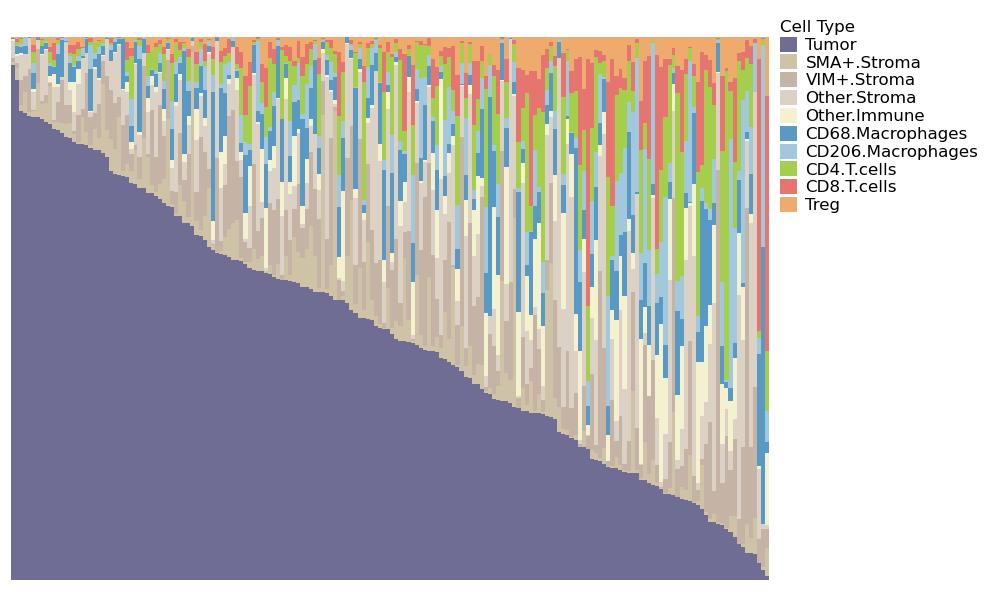

In [10]:
df = data[['patient_id_AB19_1654', 'celltype_1']]

# Group the data by patient ID and celltype columns
count_df = df.groupby(['patient_id_AB19_1654', 'celltype_1']).size().unstack(fill_value=0)

# Get the total counts of each patient
total_counts = df['patient_id_AB19_1654'].value_counts().sort_index()
# Calculate the percentage of each cell type in each patient
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
custom_order = ['Tumor', 'SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 'Other.Immune', 
                'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg'
                ]
# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)

# Sort by Tumor ratio from high to low
sorted_samples = percent_df.sort_values(by='Tumor', ascending=False).index.tolist()
# Sort the data
sorted_data = percent_df.loc[sorted_samples, custom_order]

# Define colors for each cell type
colors_dict = {
    'SMA+.Stroma': '#cec3a7',
    'VIM+.Stroma': '#c5b3a5',
    'Other.Stroma': '#dbd1c5',
    'Tumor': '#706d94',
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
sorted_data.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in sorted_data.columns], 
                ax=ax, width=1.05, edgecolor='none')


# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([])
plt.xticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/cell_types_by_patients_dpi300.pdf', bbox_inches='tight', dpi=300)
plt.show()


## Figure 3b -- cell-type by RCNs

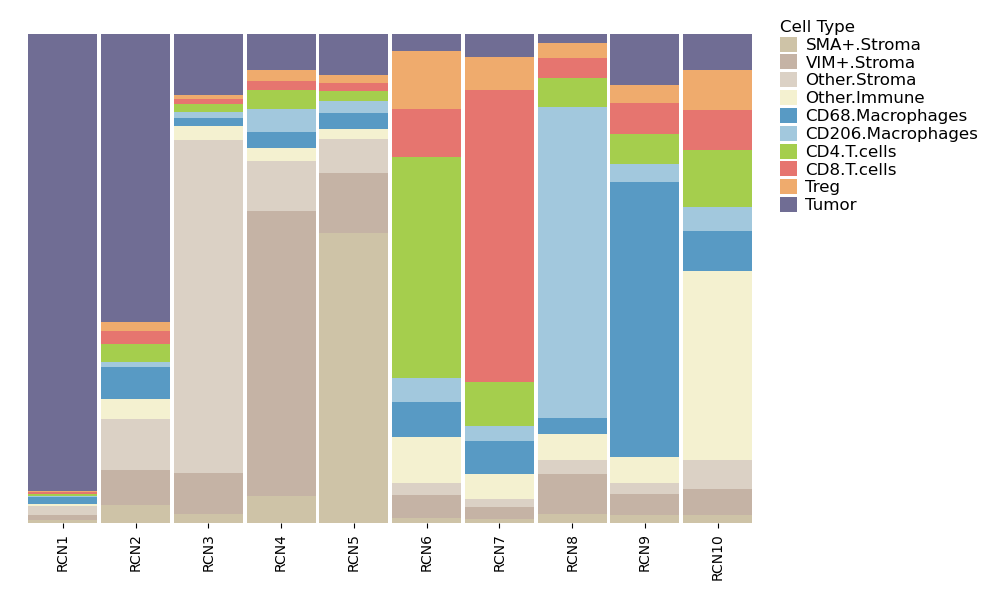

In [ ]:

df = data[['RCNs', 'celltype_1']]

# Group the data by RCNs and celltype columns
count_df = df.groupby(['RCNs', 'celltype_1']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['RCNs'].value_counts().sort_index()
# Calculate the percentage of each cell type in each RPD
percent_df = count_df.div(total_counts, axis=0) * 100

# Create a custom order based on cell types
#custom_order = ['SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 
#                'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 'Other.Immune', 
#                'Tumor']
custom_order = ['SMA+.Stroma', 'VIM+.Stroma', 'Other.Stroma', 
                'Other.Immune', 'CD68.Macrophages', 'CD206.Macrophages', 'CD4.T.cells', 'CD8.T.cells', 'Treg', 
                'Tumor']

# Reorder the columns according to the custom_order
percent_df = percent_df.reindex(columns=custom_order)
# Sort the RCNs numerically
sorted_rcns = sorted(percent_df.index, key=lambda x: int(x[3:]) if x[3:].isdigit() else float('inf'))
percent_df = percent_df.reindex(sorted_rcns)


# Define colors for each cell type
colors_dict = {
    'SMA+.Stroma': '#cec3a7',
    'VIM+.Stroma': '#c5b3a5',
    'Other.Stroma': '#dbd1c5',
    'Tumor': '#706d94',
    'CD206.Macrophages': '#A2C8DD', 
    'CD68.Macrophages': '#589AC4',
    'CD4.T.cells': '#A5CE4D',   
    'CD8.T.cells': '#E6756F',    
    'Treg': '#EFAB6D',   
    'Other.Immune': '#f4f1d0',    
}

# Set the style
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
percent_df.plot(kind='bar', stacked=True, color=[colors_dict.get(x) for x in percent_df.columns], 
                ax=ax, width=0.95, edgecolor='none')

# Add the legend outside the plot
legend = plt.legend(title='Cell Type', bbox_to_anchor=(1.0, 1), 
           loc='upper left', fontsize=12,
           frameon=False,
           handleheight=1.0, handlelength=1.0,
           handletextpad=0.5, labelspacing=0.1,
           borderpad=0.1)
#legend.get_title().set_fontweight('bold')
legend.get_title().set_fontsize(12)  # Increase title font size
legend._legend_box.align = "left"

for spine in ax.spines.values():
    spine.set_visible(False)
plt.yticks([]) 

# Add labels and title
plt.title('', fontsize=12)
plt.xlabel('', fontsize=12)
plt.ylabel('', fontsize=12)
plt.xticks(rotation=90)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent label cutoff
plt.tight_layout()


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/cell_types_by_RCNs_2.pdf', bbox_inches='tight')
plt.show()

## Figure 3b -- Total counts

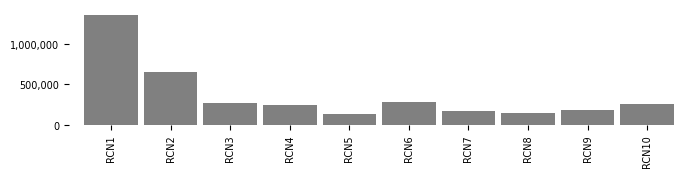

In [25]:
# Plot the stacked bar plot
# Reorder total_counts to match the order of percent_df
total_counts_reordered = total_counts.reindex(percent_df.index)

ax = total_counts_reordered.plot(kind='bar', stacked=False, figsize=(8, 1.5),
                                 color='gray', width=0.9, edgecolor='none')
for spine in ax.spines.values():
    spine.set_visible(False)

#plt.xticks([])
#plt.yticks([])  
xlim = ax.get_xlim()
ax.set_xlim(xlim[0] - 0.01, xlim[1])

# Add the total counts to the plot
#for i, total in enumerate(total_counts_reordered):
#    ax.text(i, total + 50, f"{total:,}", ha='center', va='bottom', fontsize=7)

# Add labels and title
plt.title('', fontsize=8)
plt.ylabel('', fontsize=8)
plt.xlabel('', fontsize=8)
plt.xticks(rotation=90,fontsize=7)
plt.yticks(fontsize=7)

# Disable scientific notation on y-axis
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/total_counts_by_RCNs_dpi200.pdf', bbox_inches='tight', dpi=200)
plt.show()

# Antiox markers expression by RCNs

## SFigure 3d -- All cells

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

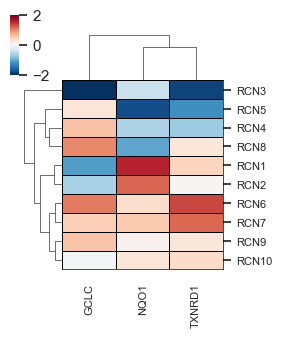

In [ ]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
RCNs = ['RCN1', 'RCN2', 'RCN3', 'RCN4', 'RCN5', 'RCN6', 'RCN7', 'RCN8', 'RCN9', 'RCN10']


expression_data = []
for RCN in RCNs:
    RCN_data = data[data['RCNs'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
#plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_all.pdf', bbox_inches='tight', dpi=500)
plt.show()

## Figure 3d -- Tumor cells

In [4]:
data_tumor = data[data['celltype_1'] == 'Tumor']

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

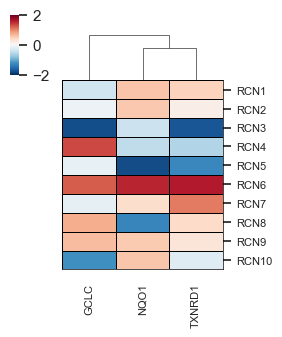

In [5]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
#RCNs = ['RCN3', 'RCN5', 'RCN4', 'RCN8', 'RCN1', 'RCN2', 'RCN6', 'RCN7', 'RCN9', 'RCN10']
RCNs = ['RCN1', 'RCN2', 'RCN3', 'RCN4', 'RCN5', 'RCN6', 'RCN7', 'RCN8', 'RCN9', 'RCN10']

expression_data = []
for RCN in RCNs:
    RCN_data = data_tumor[data_tumor['RCNs'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  row_cluster=False,
                  col_cluster=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_tumor_withoutTree_ordered.pdf', bbox_inches='tight', dpi=500)
plt.show()

/Users/wenqchen/miniconda/envs/napari-env/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning:

``square=True`` ignored in clustermap



<Figure size 400x300 with 0 Axes>

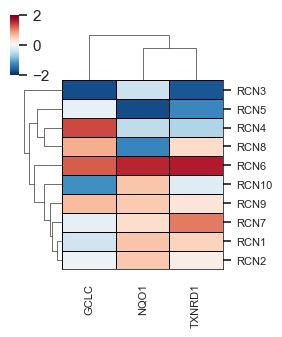

In [6]:

markers = ['GCLC', 'NQO1', 'TXNRD1']
RCNs = ['RCN1', 'RCN2', 'RCN3', 'RCN4', 'RCN5', 'RCN6', 'RCN7', 'RCN8', 'RCN9', 'RCN10']


expression_data = []
for RCN in RCNs:
    RCN_data = data_tumor[data_tumor['RCNs'] == RCN][markers].mean()
    expression_data.append(RCN_data)

df = pd.DataFrame(expression_data, index=RCNs, columns=markers)

df_zscore = (df - df.mean()) / df.std()


plt.figure(figsize=(4, 3))
g = sns.clustermap(df_zscore, 
                  cmap='RdBu_r', 
                  center=0,   
                  vmin=-2,    
                  vmax=2,         
                  xticklabels=True,
                  yticklabels=True,
                  dendrogram_ratio=0.2,
                  cbar_pos=(0.02, 0.8, 0.03, 0.2),
                  linewidths=0.5,
                  linecolor='black',
                  square=True,
                  figsize=(3, 3)
                 )

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.5)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='center', fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


plt.suptitle('', y=1.02)

# Save as PDF
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_RCNs_tumor.pdf', bbox_inches='tight', dpi=500)
plt.show()

# Marker expression by celltypes

## Figure 3a -- All cells

In [4]:
# add one column shows celltype + annotation
data['celltype_Annotation'] = data['celltype_1'] + '_' + data['Annotation']

In [5]:
data_subset = data[['GCLC', 'NQO1', 'TXNRD1', 'celltype_1', 'Annotation', 'celltype_Annotation']]
data_subset

,GCLC,NQO1,TXNRD1,celltype_1,Annotation,celltype_Annotation
CellID,,,,,,
1,0.170813,0.133212,0.233933,Other.Stroma,Invasive border,Other.Stroma_Invasive border
10,0.288927,0.920970,0.574179,Tumor,Tumor center,Tumor_Tumor center
10,0.392473,0.527165,0.330708,CD68.Macrophages,Invasive border,CD68.Macrophages_Invasive border
100,0.278554,0.864835,0.515391,Tumor,Tumor center,Tumor_Tumor center
100,0.377826,0.444848,0.293672,Other.Immune,Invasive border,Other.Immune_Invasive border
...,...,...,...,...,...,...
99998,0.456331,0.446660,0.452719,Tumor,Inflammation,Tumor_Inflammation
99999,0.640434,0.422046,0.499728,Treg,Tumor center,Treg_Tumor center
99999,0.526600,0.421663,0.475171,CD4.T.cells,Lymph node met,CD4.T.cells_Lymph node met


In [6]:
# Create a heatmap of the expression of the markers by cell type and annotation

# Define the markers and cell type annotations
markers = ['GCLC', 'NQO1', 'TXNRD1']
celltype_Annotation = data_subset['celltype_Annotation'].unique()
# Get the mean expression of the markers for each cell type annotation
expression_data = []
for CA in celltype_Annotation:
    CA_data = data_subset[data_subset['celltype_Annotation'] == CA][markers].mean()
    expression_data.append(CA_data)
# Create a DataFrame from the expression data and calculate the z-scores
df = pd.DataFrame(expression_data, index=celltype_Annotation, columns=markers)
df_zscore = (df - df.mean()) / df.std()

In [7]:
df_zscore_all = df_zscore

/var/folders/rq/68pl8_s15_lc84mft22mqf012ws2td/T/ipykernel_67979/516618508.py:91: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



<Figure size 800x700 with 0 Axes>

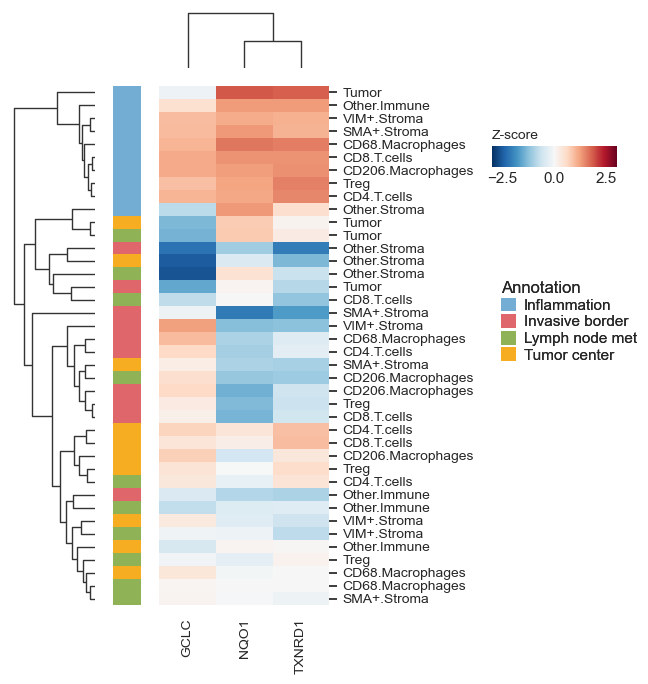

In [8]:
# Create row annotations DataFrame
row_colors = pd.DataFrame(index=celltype_Annotation)
row_colors['Annotation'] = [x.split('_')[1] for x in celltype_Annotation]
# Define color mappings
annotation_colors = {
    'Inflammation': '#73add3',    
    'Invasive border': '#df676b', 
    'Lymph node met': '#8fb257',  
    'Tumor center': '#f6ad22'     
}
# Create the color lists for each annotation
annotation_colors_list = pd.Series(row_colors['Annotation']).map(annotation_colors)


# Create the heatmap
plt.figure(figsize=(8, 7))
g = sns.clustermap(df_zscore,
                   cmap="RdBu_r",
                   center=0,
                   vmin=-3,
                   vmax=3,
                   figsize=(5, 7),
                   xticklabels=True,
                   yticklabels=True,
                   row_cluster=True,
                   col_cluster=True,
                   dendrogram_ratio=(.3, .1),
                   row_colors=[annotation_colors_list],
                   colors_ratio=0.1,
                   cbar_pos=(0.02, 0.8, 0.05, 0.18),
                   tree_kws={'linewidths': 1.0}
                   )

# Modify y-axis labels to only show the part before "_"
y_labels = [label.get_text().split('_')[0] for label in g.ax_heatmap.get_yticklabels()]
g.ax_heatmap.set_yticklabels(y_labels)
plt.subplots_adjust(right=0.7)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=10, rotation=90)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=10)
#g.ax_heatmap.tick_params(axis='x', length=0)
#g.ax_heatmap.tick_params(axis='y', length=0)

# remove the legends
if hasattr(g, 'legend_out'):
    g.legend_out.remove()
if hasattr(g, 'cax'):
    g.cax.remove()
    
    
# Add the annotations to the heatmap
legend_x = 1.0 # x location of the legend
# Add the colorbar
cbar_ax = g.fig.add_axes([legend_x, 0.75, 0.25, 0.03])  # [x, y, width, height]
cbar_ax.set_title('Z-score', fontsize=10, fontweight='normal', loc='left', pad=5)

# place the colorbar horizontally
norm = plt.Normalize(vmin=-3, vmax=3)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.outline.set_visible(False) # remove the outline of the colorbar
cbar_ax.tick_params(size=0, labelbottom=True, labeltop=False)
cbar_ax.xaxis.set_ticks_position('bottom') 


legend_y1 = 0.6  # y location of the first legend
# Add the annotations legend
annotation_handles = [plt.Rectangle((0, 0), 0.7, 1, color=annotation_colors[label], ec="none") 
                      for label in annotation_colors.keys()]
annotation_labels = list(annotation_colors.keys())
legend = g.fig.legend(annotation_handles, annotation_labels, 
                           title='Annotation', 
                           loc='upper left',
                           bbox_to_anchor=(legend_x, 0.6),
                           frameon=False,
                           handleheight=1.0, 
                           handlelength=1.0,
                           handletextpad=0.5,
                           labelspacing=0.1,
                           borderpad=0.1,
                           markerscale=1.0)

g.fig.add_artist(legend)
legend._legend_box.align = "left"
#legend.get_title().set_fontweight('bold')



#plt.suptitle('Gene Expression Heatmap', y=0.98)
plt.tight_layout()
plt.savefig('/Users/wenqchen/Desktop/Projects/Auria/Plots/antiox_markers_expression_by_all_annotation_dpi300.pdf', bbox_inches='tight', dpi=300)
# plt.show()